# Hybrid LSTM-Transformer for RONIN Heading Estimation

This notebook is designed to work with the preprocessing pipeline that saves:

- `X_train.npy`, `y_train.npy`
- `X_val.npy`, `y_val.npy`
- `X_test.npy`, `y_test.npy`

It follows the assignment template:

- Input shape: **(200, 9)**
- Output: **[sin(heading), cos(heading)]**
- Training split: `train_dataset_1 + train_dataset_2`
- Validation split: `seen_subjects_test_set`
- Test split: `unseen_subjects_test_set`

## 1. Imports

In [27]:
import math
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## 2. Load preprocessed arrays
Run your preprocessing notebook first so these files exist in the same folder as this notebook.

In [28]:
DATA_FILES = [
    "X_train.npy", "y_train.npy",
    "X_val.npy", "y_val.npy",
    "X_test.npy", "y_test.npy"
]

missing = [f for f in DATA_FILES if not Path(f).exists()]
if missing:
    raise FileNotFoundError(
        "Missing required files: " + ", ".join(missing) +
        "\nRun your preprocessing notebook first."
    )

X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

X_train: (198036, 200, 9) y_train: (198036, 2)
X_val:   (82656, 200, 9) y_val:   (82656, 2)
X_test:  (76894, 200, 9) y_test:  (76894, 2)


## 3. Sanity checks
Expected target format is `[sin(heading), cos(heading)]`.

In [29]:
assert X_train.ndim == 3 and X_train.shape[1:] == (200, 9), f"Expected X_train shape (N, 200, 9), got {X_train.shape}"
assert y_train.ndim == 2 and y_train.shape[1] == 2, f"Expected y_train shape (N, 2), got {y_train.shape}"

print("Input and target shapes look correct.")
print("Example target row [sin, cos]:", y_train[0])

Input and target shapes look correct.
Example target row [sin, cos]: [0.96417726 0.26525876]


## 4. Data loaders

In [30]:
BATCH_SIZE = 256

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

## 5. Hybrid LSTM-Transformer model
Architecture used:

- LSTM: 2 layers, hidden size 128, dropout 0.3
- Transformer: 2 encoder layers, 4 heads, model dim 128, FF dim 256, dropout 0.2
- Fusion: last LSTM hidden state + mean pooled Transformer output
- Output: 2 neurons for `[sin(heading), cos(heading)]`

In [31]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]

In [32]:
class HybridLSTMTransformer(nn.Module):
    def __init__(
        self,
        input_dim: int = 9,
        lstm_hidden: int = 64,
        lstm_layers: int = 2,
        transformer_dim: int = 128,
        num_heads: int = 2,
        transformer_layers: int = 2,
        ff_dim: int = 128,
        lstm_dropout: float = 0.3,
        transformer_dropout: float = 0.2,
        fc_hidden: int = 64,
        output_dim: int = 2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=lstm_dropout if lstm_layers > 1 else 0.0
        )

        self.proj = nn.Linear(lstm_hidden, transformer_dim)
        self.pos_encoder = PositionalEncoding(transformer_dim, max_len=200)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=transformer_dropout,
            activation="relu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=transformer_layers
        )

        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden + transformer_dim, fc_hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(fc_hidden, output_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, 200, 9)
        lstm_out, (h_n, _) = self.lstm(x)      # lstm_out: (batch, 200, 128)
        lstm_last = h_n[-1]                    # (batch, 128)

        trans_in = self.proj(lstm_out)         # (batch, 200, 128)
        trans_in = self.pos_encoder(trans_in)
        trans_out = self.transformer(trans_in) # (batch, 200, 128)
        trans_pool = trans_out.mean(dim=1)     # (batch, 128)

        fused = torch.cat([lstm_last, trans_pool], dim=1)  # (batch, 256)
        out = self.fc(fused)                   # (batch, 2)
        return out

## 6. Initialise training objects

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = HybridLSTMTransformer().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", total_params)

Using device: cpu
Trainable parameters: 272450


## 7. Training loop

In [34]:
NUM_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 7
MODEL_PATH = "best_hybrid_lstm_transformer.pth"

train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs_without_improvement = 0

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            preds = model(xb)
            loss = criterion(preds, yb)

            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * xb.size(0)

    return running_loss / len(loader.dataset)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"LR: {current_lr:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break

training_time_sec = time.time() - start_time
print(f"Training finished in {training_time_sec:.2f} seconds")

Epoch 01/15 | Train Loss: 0.451293 | Val Loss: 0.428484 | LR: 0.001000
Epoch 02/15 | Train Loss: 0.394701 | Val Loss: 0.396461 | LR: 0.001000
Epoch 03/15 | Train Loss: 0.360271 | Val Loss: 0.385365 | LR: 0.001000
Epoch 04/15 | Train Loss: 0.338600 | Val Loss: 0.380739 | LR: 0.001000
Epoch 05/15 | Train Loss: 0.320918 | Val Loss: 0.381845 | LR: 0.001000
Epoch 06/15 | Train Loss: 0.309929 | Val Loss: 0.377968 | LR: 0.001000
Epoch 07/15 | Train Loss: 0.299382 | Val Loss: 0.374756 | LR: 0.001000
Epoch 08/15 | Train Loss: 0.291559 | Val Loss: 0.370420 | LR: 0.001000
Epoch 09/15 | Train Loss: 0.284145 | Val Loss: 0.375907 | LR: 0.001000
Epoch 10/15 | Train Loss: 0.279715 | Val Loss: 0.373610 | LR: 0.001000
Epoch 11/15 | Train Loss: 0.273997 | Val Loss: 0.371194 | LR: 0.001000
Epoch 12/15 | Train Loss: 0.270672 | Val Loss: 0.371303 | LR: 0.000500
Epoch 13/15 | Train Loss: 0.255008 | Val Loss: 0.375490 | LR: 0.000500
Epoch 14/15 | Train Loss: 0.250128 | Val Loss: 0.376793 | LR: 0.000500
Epoch 

## 8. Plot loss curves

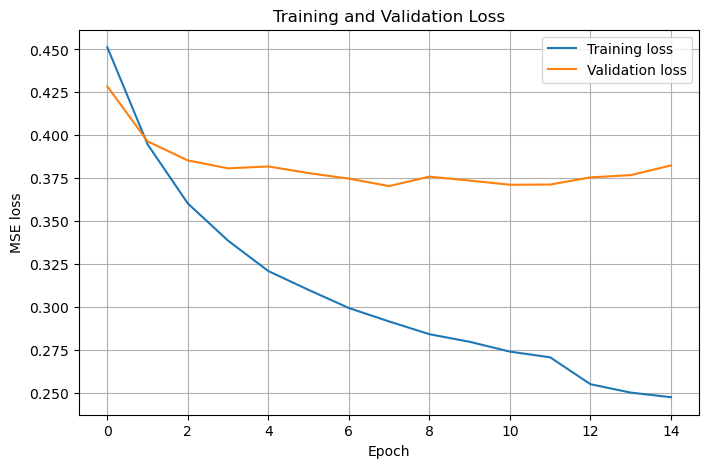

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 9. Evaluation helpers
The preprocessing notebook stores targets as `[sin(heading), cos(heading)]`.
So angle conversion must use `arctan2(sin, cos)`.

In [36]:
def sincos_to_degrees(arr: np.ndarray) -> np.ndarray:
    # arr[:, 0] = sin(theta), arr[:, 1] = cos(theta)
    angles = np.degrees(np.arctan2(arr[:, 0], arr[:, 1]))
    return (angles + 360) % 360

def circular_error_deg(pred_deg: np.ndarray, true_deg: np.ndarray) -> np.ndarray:
    diff = np.abs(pred_deg - true_deg)
    return np.minimum(diff, 360 - diff)

def circular_mae_rmse(pred_deg: np.ndarray, true_deg: np.ndarray):
    err = circular_error_deg(pred_deg, true_deg)
    mae = float(np.mean(err))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    return mae, rmse, err

## 10. Evaluate on test set

In [37]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(yb.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

pred_deg = sincos_to_degrees(all_preds)
true_deg = sincos_to_degrees(all_targets)

test_mae, test_rmse, test_err = circular_mae_rmse(pred_deg, true_deg)

print(f"Test MAE:  {test_mae:.4f} degrees")
print(f"Test RMSE: {test_rmse:.4f} degrees")
print(f"Approximate training time: {training_time_sec:.2f} seconds")

Test MAE:  66.3092 degrees
Test RMSE: 82.9964 degrees
Approximate training time: 19949.23 seconds


## 11. Predicted vs ground truth plot
This plots the first 1000 test windows. You can change the slice if needed.

In [43]:
import os
import h5py
from torch.utils.data import DataLoader, TensorDataset

WINDOW_SIZE = 200
STRIDE = 50
SAMPLING_RATE = 200

def create_windows(X, y, window_size=200, stride=50):
    X_windows = []
    y_windows = []
    for start in range(0, len(X) - window_size, stride):
        end = start + window_size
        X_windows.append(X[start:end])
        y_windows.append(y[end - 1])  # target at end of window
    return np.array(X_windows), np.array(y_windows)

def load_sequence(seq_path):
    with h5py.File(seq_path, 'r') as f:
        acce = f['synced']['acce'][:]
        gyro = f['synced']['gyro'][:]
        magnet = f['synced']['magnet'][:]
        tango_pos = f['pose']['tango_pos'][:]

    dx = np.diff(tango_pos[:, 0])
    dy = np.diff(tango_pos[:, 1])
    heading = np.arctan2(dy, dx)

    acce = acce[1:]
    gyro = gyro[1:]
    magnet = magnet[1:]

    X = np.concatenate([acce, gyro, magnet], axis=1)
    y = np.column_stack([np.sin(heading), np.cos(heading)])
    return X, y

def sincos_to_deg(arr):
    deg = np.degrees(np.arctan2(arr[:, 0], arr[:, 1]))
    return (deg + 360) % 360

In [44]:
test_root = "unseen_subjects_test_set"
seq_name = sorted(os.listdir(test_root))[0]   # first full test trajectory
seq_path = os.path.join(test_root, seq_name, "data.hdf5")

print("Using full test trajectory:", seq_name)

X_seq_raw, y_seq_raw = load_sequence(seq_path)
X_seq_win, y_seq_win = create_windows(X_seq_raw, y_seq_raw, WINDOW_SIZE, STRIDE)

mean = np.load("mean.npy")
std = np.load("std.npy")
X_seq_win = (X_seq_win - mean) / std

X_seq_t = torch.tensor(X_seq_win, dtype=torch.float32)
seq_loader = DataLoader(TensorDataset(X_seq_t), batch_size=256, shuffle=False)

model.eval()
seq_preds = []

with torch.no_grad():
    for (xb,) in seq_loader:
        xb = xb.to(device)
        out = model(xb).cpu().numpy()
        seq_preds.append(out)

seq_preds = np.concatenate(seq_preds, axis=0)

pred_deg_seq = sincos_to_deg(seq_preds)
true_deg_seq = sincos_to_deg(y_seq_win)

time_sec = (np.arange(len(pred_deg_seq)) * STRIDE + (WINDOW_SIZE - 1)) / SAMPLING_RATE

print("Number of windows in this full trajectory:", len(pred_deg_seq))

Using full test trajectory: a006_2
Number of windows in this full trajectory: 3475


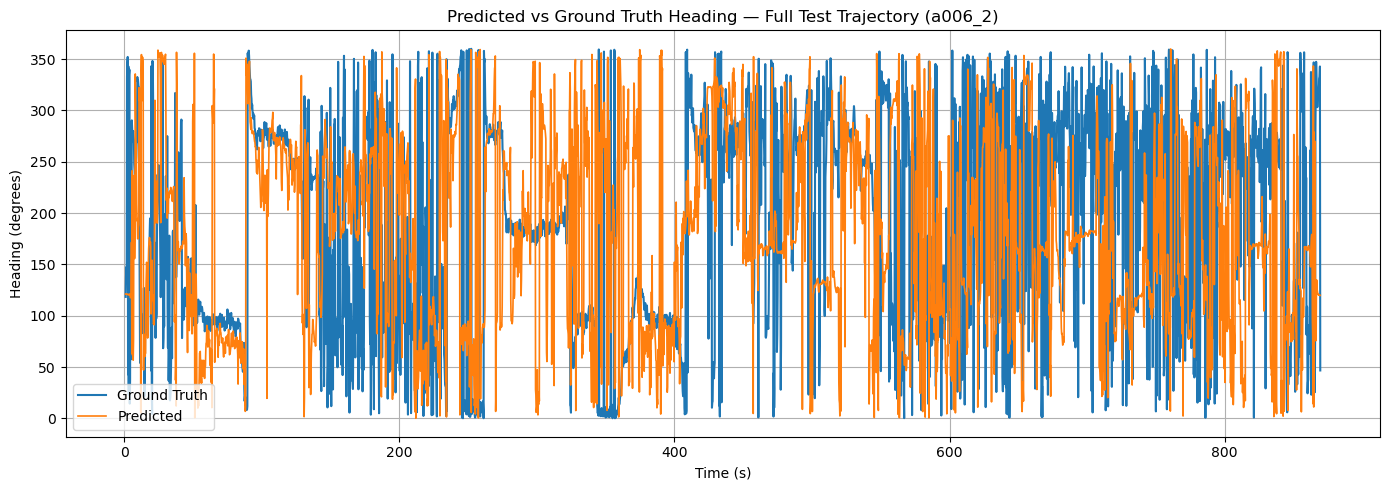

In [45]:
plt.figure(figsize=(14, 5))
plt.plot(time_sec, true_deg_seq, label="Ground Truth", linewidth=1.5)
plt.plot(time_sec, pred_deg_seq, label="Predicted", linewidth=1.2)
plt.xlabel("Time (s)")
plt.ylabel("Heading (degrees)")
plt.title(f"Predicted vs Ground Truth Heading — Full Test Trajectory ({seq_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pred_vs_true_full_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Optional: save predictions for report figures

In [40]:
np.save("hybrid_pred_deg.npy", pred_deg)
np.save("hybrid_true_deg.npy", true_deg)
print("Saved: hybrid_pred_deg.npy, hybrid_true_deg.npy")

Saved: hybrid_pred_deg.npy, hybrid_true_deg.npy


In [42]:
import os
print(os.path.exists("best_hybrid_lstm_transformer.pth"))

True
